<a href="https://colab.research.google.com/github/count-im/test/blob/main/LLM_Application/LLM03/LLM03_LangGraph_ReportAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM03 — LangGraph ReportAgent

**AIFFEL GenAI DAY5**

LangGraph를 활용한 ReportAgent 구현
- 검색(SerpAPI) → 코드 실행(PythonREPL) → PDF 생성(fpdf) 파이프라인
- 단기 기억 + 히스토리 기반 분기 + 답변 품질 자동 검증

---

**그래프 흐름:**
```
START → history_node → [history_check]
                         ├─ yes → memory_chat → END
                         └─ no  → select → tools → response → [answer_check]
                                                                  ├─ end  → END
                                                                  └─ tool → select (loop)
```

In [26]:
# Cell 1 — 패키지 설치
# google-search-results: SerpAPI Python 클라이언트
!pip install -q langchain langgraph langchain-openai langchain-core langchain-community langchain-experimental fpdf pdfplumber google-search-results

In [27]:
# Cell 1b — 한글 폰트 설치 (write_pdf 한글 깨짐 방지)
!apt-get install -y fonts-nanum
!fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [28]:
# Cell 2 — API Key 설정
# 1순위: 환경변수 | 2순위: Colab Secrets | 3순위: 직접 입력 (getpass)
import os
import getpass

def get_api_key(key_name: str) -> str:
    """
    API Key 입력 함수.
    1순위: 이미 환경변수에 설정되어 있으면 그대로 사용
    2순위: Colab Secrets에 등록되어 있으면 사용
    3순위: 실행 시 직접 입력 요구
    """
    # 이미 설정된 경우 재사용
    if os.environ.get(key_name):
        print(f"✅ {key_name}: 환경변수에서 로드")
        return os.environ[key_name]

    # Colab Secrets 시도
    try:
        from google.colab import userdata
        value = userdata.get(key_name)
        if value:
            print(f"✅ {key_name}: Colab Secrets에서 로드")
            return value
    except Exception:
        pass

    # 직접 입력
    print(f"🔑 {key_name}를 입력하세요 (입력값은 화면에 표시되지 않습니다):")
    value = getpass.getpass(f"{key_name}: ")
    return value

os.environ["OPENAI_API_KEY"]  = get_api_key("OPENAI_API_KEY")
os.environ["SERPAPI_API_KEY"] = get_api_key("SERPAPI_API_KEY")

print("\n✅ API Key 설정 완료")

✅ OPENAI_API_KEY: 환경변수에서 로드
✅ SERPAPI_API_KEY: 환경변수에서 로드

✅ API Key 설정 완료


In [29]:
# Cell 3 — Import
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import AIMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.tools import Tool, tool
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SerpAPIWrapper
from langchain_community.agent_toolkits import FileManagementToolkit
from langchain_experimental.tools import PythonAstREPLTool
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from typing import Annotated, Literal
from typing_extensions import TypedDict
import pdfplumber
from fpdf import FPDF
import random
import os

print("✅ Import 완료")

✅ Import 완료


In [30]:
# Cell 4 — State 정의
# LangGraph 핵심 — 모든 노드가 공유하는 상태 딕셔너리
# query: 사용자 질문 | answer: 최종 답변 | messages: 대화 히스토리 | tool_call: 도구 실행 결과

class State(TypedDict):
    query: Annotated[str, "User Question"]
    answer: Annotated[str, "LLM response"]
    messages: Annotated[list, add_messages]
    tool_call: Annotated[dict, "Tool Call Result"]

In [31]:
# Cell 5 — LLM 정의
llm = ChatOpenAI(model="gpt-4o", temperature=0)
print("✅ LLM 준비 완료:", llm.model_name)

✅ LLM 준비 완료: gpt-4o


In [32]:
# Cell 6 — write_pdf 도구

@tool
def write_pdf(content: str, filename: str = "output.pdf", summary: bool = True):
    """
    텍스트를 PDF 파일로 저장하는 도구입니다.
    PDF 형태의 문서로 만들어야 할 때 이 도구를 사용하세요.
    filename 예시: 'report.pdf'
    """
    if summary:
        prompt = PromptTemplate.from_template("""
        당신은 보고서를 작성하는 어시스턴트입니다.
        아래 content를 잘 분석하여 구조화된 보고서를 작성하세요.
        항상 마지막엔 인사이트를 첨부합니다.
        content: {content}
        """)
        chain = prompt | llm
        content = chain.invoke({"content": content}).content

    pdf = FPDF()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=15)
    # Colab 한글 폰트 — apt-get install fonts-nanum 으로 설치한 NanumGothic 사용
    pdf.add_font('NanumGothic', '', '/usr/share/fonts/truetype/nanum/NanumGothic.ttf', uni=True)
    pdf.set_font('NanumGothic', size=12)
    for line in content.split('\n'):
        pdf.multi_cell(0, 8, line)
    pdf.output(filename)
    return f"✅ PDF 저장 완료: {filename}"

In [33]:
# Cell 7 — read_pdf 도구

@tool
def read_pdf(file_path: str):
    """
    PDF 파일에서 텍스트를 추출하는 도구입니다.
    file_path 예시: './report.pdf'
    """
    try:
        text = ""
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text.strip() if text.strip() else "❌ PDF에서 텍스트를 추출할 수 없습니다."
    except Exception as e:
        return f"❌ PDF 읽기 오류: {str(e)}"

In [34]:
# Cell 8 — tools 정의 (SerpAPI 직접 호출 — LangChain 래퍼 우회)
# LangChain SerpAPIWrapper의 HiddenPrints가 Colab OutStream과 충돌 → 직접 호출로 해결

from serpapi import GoogleSearch
from langchain_core.tools import Tool

def serpapi_search(query: str) -> str:
    params = {
        "engine": "google",
        "q": query,
        "api_key": os.environ["SERPAPI_API_KEY"]
    }
    search = GoogleSearch(params)
    results = search.get_dict()
    organic = results.get("organic_results", [])
    if not organic:
        return "검색 결과가 없습니다."
    return "\n".join([
        f"{r.get('title', '')}: {r.get('snippet', '')}"
        for r in organic[:8]
    ])

search = Tool(
    name="web_search",
    func=serpapi_search,
    description="웹 검색 도구. 최신 정보, 인물, 회사, 연구 동향 검색 시 사용."
)

tools = [
    search,
    PythonAstREPLTool(),
    write_pdf,
    read_pdf,
    *FileManagementToolkit(selected_tools=["file_delete", "list_directory"]).get_tools()
]

search_tool, code_tool, write_tool, read_tool, delete_tool, listdir_tool = tools
print("✅ Tools 정의 완료")

✅ Tools 정의 완료


In [35]:
# Cell 9 — LLM에 도구 바인딩
llm_with_tools = llm.bind_tools(tools)
print("✅ LLM + Tools 바인딩 완료")

✅ LLM + Tools 바인딩 완료


In [36]:
# Cell 10 — 단기 기억 함수
# 메시지 히스토리 최대 8개 유지 (토큰 절약)

def shorterm_memory(state: State):
    if len(state["messages"]) > 8:
        history = state["messages"][-8:-1]
    elif len(state["messages"]) == 1:
        history = ""
    else:
        history = state["messages"][:-1]
    return history

In [37]:
# Cell 11 — HistoryChecker (구조화 출력)
# 이전 대화 기록으로 질문에 답변 가능한지 판단 — yes/no 반환

class HistoryChecker(BaseModel):
    """이전 대화 기록으로 질문에 답변 가능한지 판단. yes/no 반환."""
    yes_no: Literal["yes", "no"] = Field(..., description="답변 가능하면 yes, 불가능하면 no")

history_checker = llm.with_structured_output(HistoryChecker)

In [38]:
# Cell 12 — AnswerChecker (구조화 출력)
# 정답이 질문을 해결했는지 판단 — end/tool 반환

class AnswerChecker(BaseModel):
    """정답이 질문을 해결했는지 판단. end/tool 반환."""
    end: Literal["end", "tool"] = Field(..., description="해결됐으면 end, 미해결이면 tool")

answer_checker = llm.with_structured_output(AnswerChecker)

In [39]:
# Cell 13 — 노드 함수 정의
# history_check, memory_chat, history_node, select, response, answer_check

def history_check(state: State):
    # 히스토리 기반 답변 가능 여부 분기 — yes면 memory_chat, no면 select
    prompt = PromptTemplate.from_template("""
    이전 대화 기록을 참고해 질문에 답변할 수 있는지 판단하세요.
    대화 기록: {history}
    질문: {query}
    """)
    chain = prompt | history_checker
    result = chain.invoke({"history": shorterm_memory(state), "query": state["query"]})
    return result.yes_no


def memory_chat(state: State):
    # 히스토리로 답변 가능한 경우 — 새 검색 없이 응답
    prompt = PromptTemplate.from_template("""
    이전 대화 기록을 참고해 답변하세요.
    대화 기록: {history}
    질문: {query}
    """)
    chain = prompt | llm
    result = chain.invoke({"history": shorterm_memory(state), "query": state["query"]})
    if len(state["tool_call"]) == 0:
        return {"answer": result.content, "messages": result, "tool_call": {}}
    return {"answer": result.content, "messages": result}


def history_node(state: State):
    # 첫 메시지 여부 확인 — 히스토리 없으면 빈 값으로 초기화
    if len(state["messages"]) == 1:
        return {"answer": "답변 없음", "tool_call": "사용된 도구 없음"}
    return state


def select(state: State):
    # 도구 선택 노드 — 히스토리와 질문을 보고 LLM이 적절한 도구 호출 결정
    prompt = PromptTemplate.from_template("""
    이전 대화 기록과 질문을 분석해 가장 적절한 도구를 선택하세요.
    대화 기록: {history}
    최근 사용 도구: {tool_name}
    정답: {answer}
    질문: {query}
    """)
    chain = prompt | llm_with_tools
    result = chain.invoke({
        "history": shorterm_memory(state),
        "tool_name": state["tool_call"],
        "answer": state["answer"],
        "query": state["query"]
    })
    return {"messages": result, "tool_call": result.tool_calls if result.tool_calls else {}}


def response(state: State):
    # 도구 실행 결과를 answer에 저장
    return {"answer": state["messages"][-1]}


def answer_check(state: State):
    # 답변이 질문을 완전히 해결했는지 판단 — end면 종료, tool이면 select 루프 반복
    prompt = PromptTemplate.from_template("""
    정답이 질문을 해결했는지 판단하세요.
    History: {history}
    정답: {answer}
    질문: {query}
    """)
    chain = prompt | answer_checker
    result = chain.invoke({
        "history": shorterm_memory(state),
        "answer": state["answer"],
        "query": state["query"]
    })
    return result.end


print("✅ 노드 함수 정의 완료")

✅ 노드 함수 정의 완료


In [40]:
# Cell 14 — 그래프 정의 및 컴파일
# 노드 등록 → 엣지 연결 → 조건부 분기 설정 → 메모리 체크포인터 연결

graph_builder = StateGraph(State)

# 노드 등록
graph_builder.add_node("history_node", history_node)
graph_builder.add_node("memory_chat", memory_chat)
graph_builder.add_node("select", select)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_node("response", response)

# 엣지 연결
graph_builder.add_edge(START, "history_node")
graph_builder.add_conditional_edges(
    "history_node", history_check,
    {"yes": "memory_chat", "no": "select"}
)
graph_builder.add_edge("select", "tools")
graph_builder.add_edge("tools", "response")
graph_builder.add_conditional_edges(
    "response", answer_check,
    {"end": END, "tool": "select"}
)
graph_builder.add_edge("memory_chat", END)

# 메모리 체크포인터 연결
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

print("✅ 그래프 컴파일 완료")

✅ 그래프 컴파일 완료


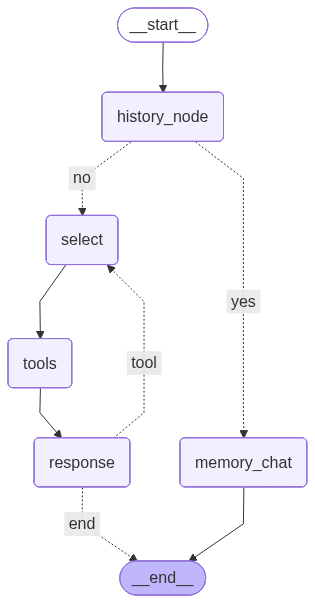

In [41]:
# Cell 15 — 그래프 시각화
graph

In [45]:
# Cell 16 — 유틸 함수

def reset_config(limit=20):
    """새 스레드 ID로 config 생성 — 대화 히스토리 초기화"""
    config = RunnableConfig(
        recursion_limit=limit,
        configurable={"thread_id": random.randint(1, 999999)}
    )
    return config


def streaming(query, config, mode="values"):
    """그래프를 스트리밍 모드로 실행하고 결과 출력"""
    result = graph.stream(
        {"messages": ("user", query), "query": query},
        config=config, stream_mode=mode
    )
    if mode == "values":
        for step in result:
            for k, v in step.items():
                if k == "messages":
                    v[-1].pretty_print()
    elif mode == "updates":
        for step in result:
            for k, v in step.items():
                print(f"\n\n=== {k} ===\n\n")
                print(v)
    return result


print("✅ 유틸 함수 준비 완료")

✅ 유틸 함수 준비 완료


In [46]:
# Cell 17 — 기본 동작 테스트
config = reset_config()
streaming("1+1은 뭐야?", config)

================================ Human Message =================================

1+1은 뭐야?
================================ Human Message =================================

1+1은 뭐야?
================================== Ai Message ==================================

질문은 간단한 수학 문제로, 계산을 통해 답을 얻을 수 있습니다. 따라서 Python을 사용하여 계산을 수행하는 것이 적절합니다. Python을 사용하여 계산을 수행하겠습니다.
Tool Calls:
  python_repl_ast (call_IhR6yU53JMzU8AkiBXCtIdEN)
 Call ID: call_IhR6yU53JMzU8AkiBXCtIdEN
  Args:
    query: 1 + 1
================================= Tool Message =================================
Name: python_repl_ast

2
================================= Tool Message =================================
Name: python_repl_ast

2


<generator object Pregel.stream at 0x35705a20>

In [47]:
# Cell 18 — 메인 실행
config = reset_config()

query = """
삼성전자에 대해 조사하고 보고서를 PDF로 저장해주세요.
파일명: "samsung_report.pdf"
"""

try:
    streaming(query, config)
except AttributeError as e:
    if "'OutStream' object has no attribute 'watch_fd_thread'" in str(e):
        print("\n--- 오류 발생 ---")
        print("LangChain의 SerpAPIWrapper에서 Colab 환경과의 호환성 문제로 인해 오류가 발생했습니다.")
        print("이 오류는 LangChain의 SerpAPI 유틸리티가 Colab의 출력 스트림(sys.stdout)을 처리하는 방식 때문에 발생합니다.")
        print("Colab의 'OutStream' 객체는 SerpAPIWrapper의 'HiddenPrints' 유틸리티가 예상하는 'watch_fd_thread' 속성을 가지고 있지 않습니다.")
        print("\n--- 해결 방법 ---")
        print("1. 가장 먼저 langchain-community 패키지를 최신 버전으로 업그레이드해보세요. 최신 버전에서 이 문제가 해결되었을 수 있습니다.")
        print("   -> '!pip install --upgrade langchain-community' 명령어를 실행해 보세요.")
        print("2. 만약 업그레이드 후에도 문제가 지속되면, SerpAPI 대신 다른 검색 도구(예: Tavily 등)를 사용하도록 변경하는 것을 고려해볼 수 있습니다.")
        print("3. SerpAPI 사용이 필수적인 경우, Colab 환경에서 stdout을 처리하는 방식에 대한 더 자세한 조사가 필요할 수 있습니다.")
        print("-----------------\n")
    else:
        raise e # 다른 AttributeError는 다시 발생시킴

================================ Human Message =================================


삼성전자에 대해 조사하고 보고서를 PDF로 저장해주세요.
파일명: "samsung_report.pdf"

================================ Human Message =================================


삼성전자에 대해 조사하고 보고서를 PDF로 저장해주세요.
파일명: "samsung_report.pdf"

================================== Ai Message ==================================
Tool Calls:
  web_search (call_4z1K2p5OQ7S2SFnfG1cbTQL7)
 Call ID: call_4z1K2p5OQ7S2SFnfG1cbTQL7
  Args:
    __arg1: 삼성전자
================================= Tool Message =================================
Name: web_search

Samsung 대한민국 | 모바일 | TV | 가전 | IT: 삼성 TV 모델인 QLED, Neo QLED, Neo QLED 8K, OLED, 그리고 The Frame 그리고, 삼성 Vision AI가 있으며, 이미지를 클릭하면 TV 기획전 페이지로 이동합니다.
삼성전자: 대한민국 삼성 그룹의 전자·반도체 제조 기업. 삼성의 계열사들 중 최대 규모의 기업'이며 대한민국 최대의 단일 기업으로, 글로벌 시장에서 한국을 대표하는 기업 브랜드 ...
삼성전자 (005930) - 네이버 금융 - NAVER: No information is available for this page.
삼성전자 005930 코스피 - 다음 금융 - Daum: 주요뉴스 · 삼성전자 제쳤다…입사하고 싶은 대기업, 1위는? JTBC|26.03.16 12:08 · '

/usr/local/lib/python3.12/dist-packages/fpdf/ttfonts.py:670: UserWarning: cmap value too big/small: -43957
  warnings.warn("cmap value too big/small: %s" % cm)
/usr/local/lib/python3.12/dist-packages/fpdf/ttfonts.py:670: UserWarning: cmap value too big/small: -43984
  warnings.warn("cmap value too big/small: %s" % cm)
/usr/local/lib/python3.12/dist-packages/fpdf/ttfonts.py:670: UserWarning: cmap value too big/small: -44085
  warnings.warn("cmap value too big/small: %s" % cm)
/usr/local/lib/python3.12/dist-packages/fpdf/ttfonts.py:670: UserWarning: cmap value too big/small: -44093
  warnings.warn("cmap value too big/small: %s" % cm)
/usr/local/lib/python3.12/dist-packages/fpdf/ttfonts.py:670: UserWarning: cmap value too big/small: -44141
  warnings.warn("cmap value too big/small: %s" % cm)
/usr/local/lib/python3.12/dist-packages/fpdf/ttfonts.py:670: UserWarning: cmap value too big/small: -44147
  warnings.warn("cmap value too big/small: %s" % cm)
/usr/local/lib/python3.12/dist-packages/

================================= Tool Message =================================
Name: write_pdf

✅ PDF 저장 완료: samsung_report.pdf
================================= Tool Message =================================
Name: write_pdf

✅ PDF 저장 완료: samsung_report.pdf
